<a href="https://colab.research.google.com/github/sreenathsnv/AI-ML/blob/DL/Deeplearning_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Pt2

## Neural Network For Handwritten Digits Classification

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [3]:
(X_train,y_train) , (X_test,y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
len(X_train)

60000

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

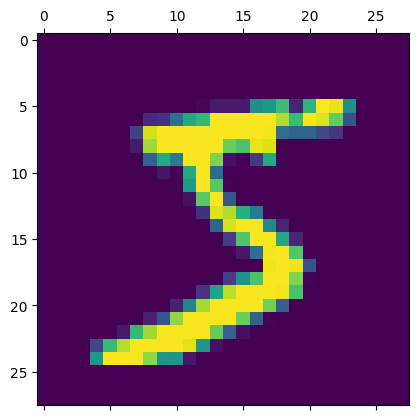

In [7]:
plt.matshow(X_train[0])

In [16]:
X_train[0].shape

(28, 28)

In [12]:
y_train[0]

np.uint8(5)

In [14]:
y_train[:9]

array([5, 0, 4, 1, 9, 2, 1, 3, 1], dtype=uint8)

#### Reshaping the 28x28 training and testing data into 28*28 flattened data for NN

In [19]:
X_test.shape

(10000, 28, 28)

In [27]:
X_train = X_train/255
X_test = X_test/255

In [29]:
X_train_flattened = X_train.reshape(60000,28*28)
X_test_flattened = X_test.reshape(10000,28*28)


In [31]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape =(784,),activation='sigmoid')
])

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # output is integer categorical values
    metrics=['accuracy']
    )

In [35]:
model.fit(X_train_flattened,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7878 - loss: 1.3599
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7989 - loss: 1.2533
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8069 - loss: 1.1616
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8154 - loss: 1.0824
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8215 - loss: 1.0139
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8281 - loss: 0.9546
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8321 - loss: 0.9030
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8372 - loss: 0.8578
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8417 - loss: 0.8181
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8464 - loss: 0.7831


In [37]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8555 - loss: 0.7468


[0.7468356490135193, 0.8554999828338623]

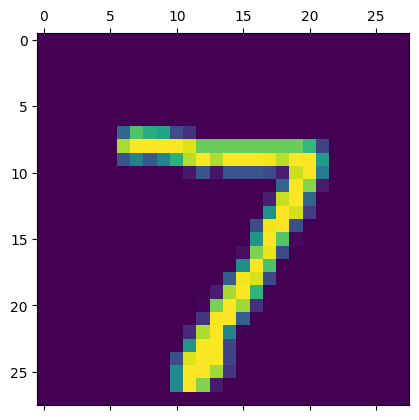

In [40]:
plt.matshow(X_test[0])

In [45]:
y_predicted = model.predict(X_test_flattened)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [44]:
np.argmax(model.predict(X_test_flattened)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.int64(7)

In [49]:
y_predicted_labels = [np.argmax(i) for i in model.predict(X_test_flattened)]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [50]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [48]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [53]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

Text(95.72222222222221, 0.5, 'Truth')

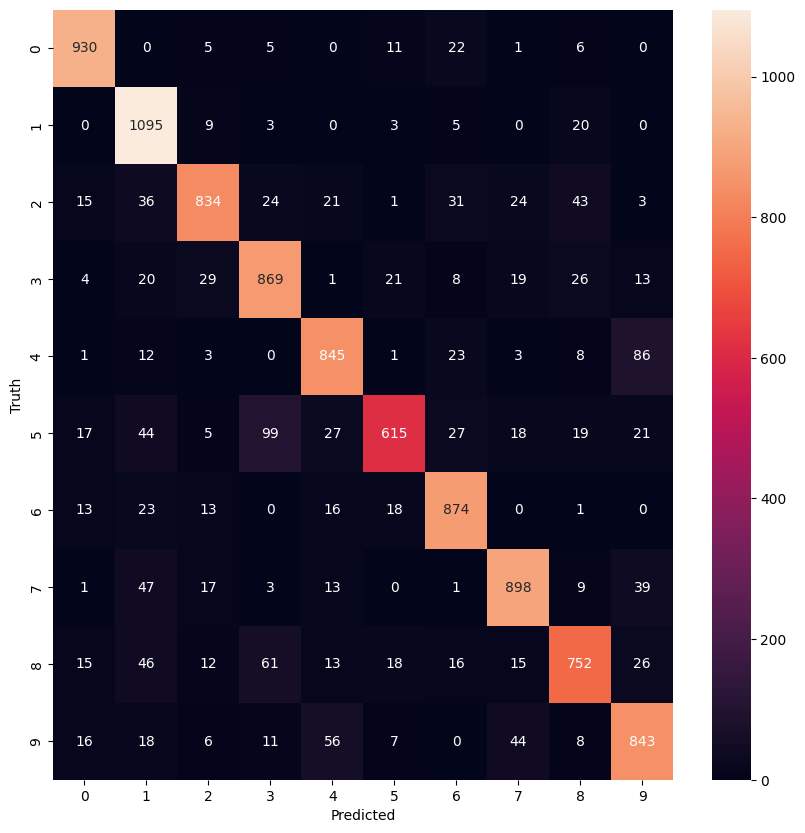

In [54]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

### With hidden layer

In [56]:
model = keras.Sequential([
    keras.layers.Dense(100,input_shape =(784,),activation='relu'),
    keras.layers.Dense(10,input_shape =(784,),activation='sigmoid')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train_flattened,y_train,epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7157 - loss: 1.2016
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8720 - loss: 0.4992
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8939 - loss: 0.3893
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9030 - loss: 0.3463
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9080 - loss: 0.3230


In [57]:
y_predicted_labels = [np.argmax(i) for i in model.predict(X_test_flattened)]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [58]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)


Text(95.72222222222221, 0.5, 'Truth')

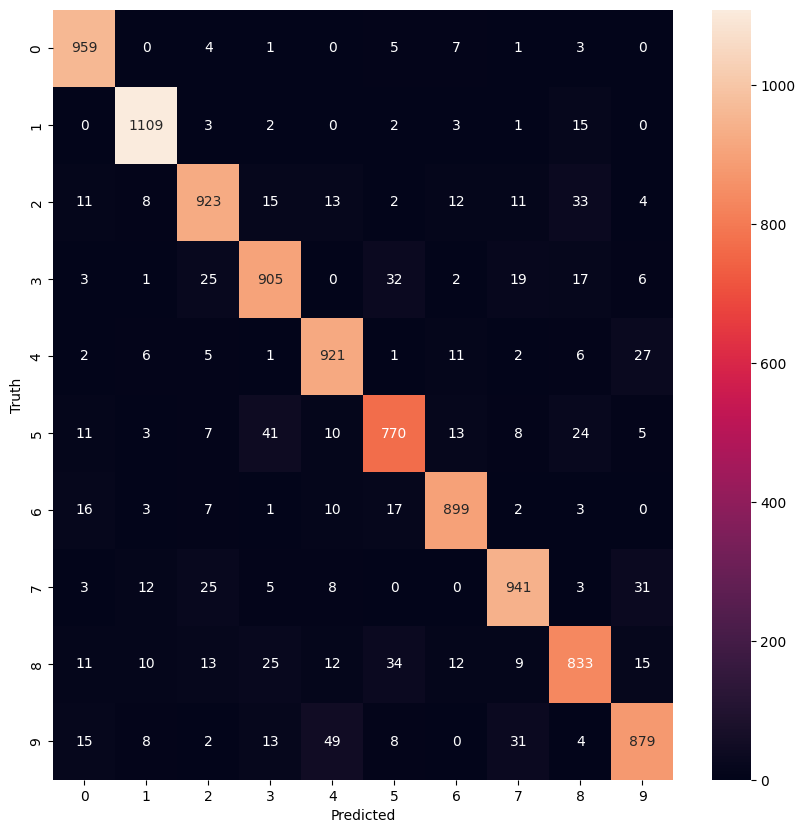

In [59]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

#### Without Flattening the X values, Flatteing with flatten layer

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7201 - loss: 0.8874
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8842 - loss: 0.3977
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9082 - loss: 0.3109
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9222 - loss: 0.2662
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9323 - loss: 0.2306
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9403 - loss: 0.2033
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9469 - loss: 0.1802
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9524 - loss: 0.1623
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9567 - loss: 0.1456
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9604 - loss: 0.1332
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9574 - loss: 0.1478
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Text(95.72222222222221, 0.5, 'Truth')

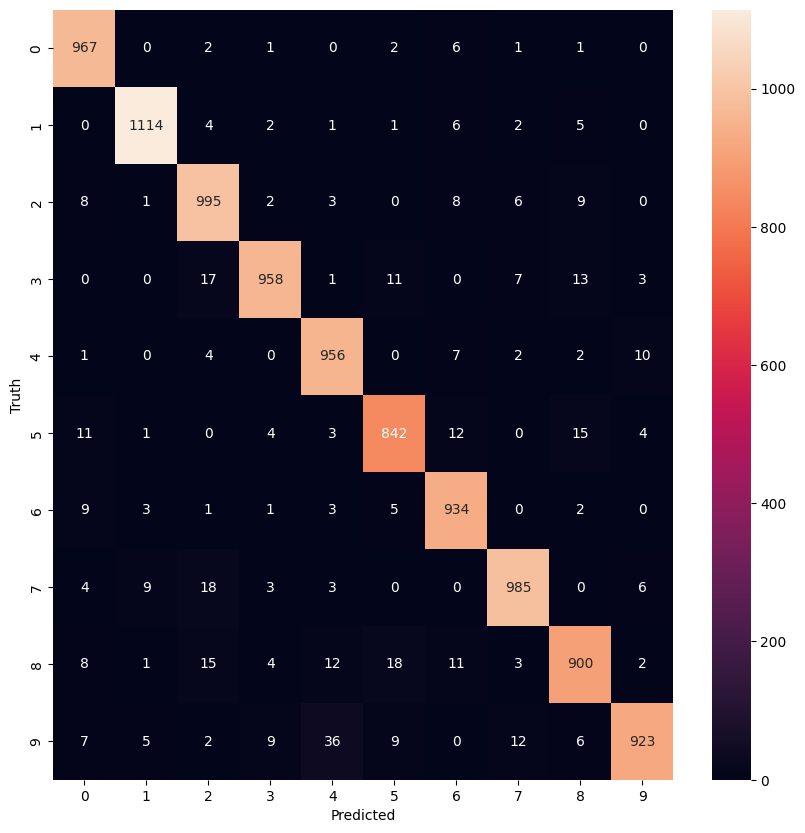

In [61]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(25,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,epochs=10)
model.evaluate(X_test,y_test)

y_predicted_labels = [np.argmax(i) for i in model.predict(X_test)]

cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


# Vanishing Gradient & Exploding Gradient + ReLU Explanation

## 🧠 1. Vanishing Gradient Problem

### 🔍 What it is
Gradients become **very small (approach 0)** during backpropagation.

### ⚙️ Why it happens
In deep networks:

$$
\text{Gradient} \approx (\text{small numbers})^{\text{many layers}} \rightarrow 0
$$

- Activation functions like **sigmoid** and **tanh** have derivatives < 1  
- Repeated multiplication → gradient shrinks

### ⚠️ Effects
- Early layers **stop learning**
- Training becomes **slow or stuck**

---

## 💥 2. Exploding Gradient Problem

### 🔍 What it is
Gradients become **very large (approach infinity)**.

### ⚙️ Why it happens
$$
\text{Gradient} \approx (\text{large numbers})^{\text{many layers}} \rightarrow \infty
$$

- Weights or derivatives > 1  
- Multiplication across layers → huge values

### ⚠️ Effects
- Weights become very large  
- Loss becomes **unstable (NaN / overflow)**  
- Training **diverges**

---

## ⚖️ Comparison

| Problem              | Cause                        | Effect                     |
|---------------------|-----------------------------|---------------------------|
| Vanishing Gradient  | Values < 1 repeatedly       | Learning stops            |
| Exploding Gradient  | Values > 1 repeatedly       | Training unstable         |

---

## 🔥 3. Why ReLU Fixes Vanishing Gradient

### 📌 ReLU Function

$$
f(x) = \max(0, x)
$$

---

### 📌 Derivative of ReLU

$$
f'(x) =
\begin{cases}
1 & x > 0 \\
0 & x \leq 0
\end{cases}
$$

---

## 🔑 Key Insight

For positive inputs:

$$
f'(x) = 1
$$

So during backpropagation:

$$
\text{Gradient} = 1 \times 1 \times 1 \times \dots = 1
$$

✅ No shrinking of gradients  
✅ Deep networks can still learn  

---

## ❌ Compare with Sigmoid

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x)) \leq 0.25
$$

Across layers:

$$
0.25 \times 0.25 \times 0.25 \dots \rightarrow 0
$$

❌ Gradients vanish quickly  

---

## ⚠️ Limitation of ReLU

- For $$ x \leq 0 $$, gradient = 0  
- Can cause **Dead Neurons**

### ✔ Fix:
- Leaky ReLU  
- Parametric ReLU  

---

## 🎯 Final Summary

- Vanishing Gradient → gradients become too small  
- Exploding Gradient → gradients become too large  
- ReLU helps → derivative = 1 (for positive inputs), so gradients **don’t vanish**

---